# Part 1e: Custom Dropout and Custom Regularization

This notebook demonstrates how to create custom dropout layers and custom regularizers in both TensorFlow/Keras and PyTorch.

## Topics Covered:
1. Custom Dropout Layers (Spatial, Alpha, Gaussian)
2. Custom Regularizers (L1, L2, Orthogonal)
3. Activity Regularization
4. Implementation in TensorFlow and PyTorch

**Author:** Advanced Deep Learning Course Assignment

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

---
# Part A: Custom Dropout and Regularization in TensorFlow/Keras

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

print(f"TensorFlow version: {tf.__version__}")
tf.random.set_seed(42)

TensorFlow version: 2.19.0


In [3]:
# Load MNIST
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0
X_train_flat = X_train.reshape(-1, 784)
X_test_flat = X_test.reshape(-1, 784)

# Use subset
X_train_flat = X_train_flat[:10000]
y_train_subset = y_train[:10000]
X_train_subset = X_train[:10000]

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## 1. Custom Dropout Layers

In [4]:
class CustomDropout(keras.layers.Layer):
    """
    Custom Dropout layer with configurable behavior.

    This implementation gives us full control over:
    - Dropout rate
    - Noise shape
    - Scaling factor

    Compatible with Keras 3.x
    """
    def __init__(self, rate=0.5, noise_shape=None, **kwargs):
        super(CustomDropout, self).__init__(**kwargs)
        self.rate = rate
        self.noise_shape = noise_shape

    def call(self, inputs, training=None):
        # Default to False if training is None
        if training is None:
            training = False

        # Only apply dropout during training
        if not training:
            return inputs

        # Generate dropout mask
        noise_shape = self.noise_shape if self.noise_shape else tf.shape(inputs)
        random_tensor = tf.random.uniform(noise_shape, dtype=inputs.dtype)
        keep_prob = 1 - self.rate

        # Create binary mask
        mask = tf.cast(random_tensor >= self.rate, inputs.dtype)

        # Scale by keep probability (inverted dropout)
        return inputs * mask / keep_prob

    def get_config(self):
        config = super().get_config()
        config.update({
            'rate': self.rate,
            'noise_shape': self.noise_shape
        })
        return config

# Test custom dropout
print("Testing Custom Dropout:")
custom_dropout = CustomDropout(rate=0.5)

test_input = tf.ones((2, 10))
print(f"Input: {test_input.numpy()}")
print(f"Output (training=True): {custom_dropout(test_input, training=True).numpy()}")
print(f"Output (training=False): {custom_dropout(test_input, training=False).numpy()}")

Testing Custom Dropout:
Input: [[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]]
Output (training=True): [[2. 0. 0. 0. 0. 2. 2. 2. 0. 0.]
 [0. 2. 0. 2. 2. 2. 0. 2. 2. 0.]]
Output (training=False): [[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]]


In [5]:
class GaussianDropout(keras.layers.Layer):
    """
    Gaussian Dropout: Multiplies inputs by Gaussian noise.

    Instead of zeroing out neurons, we multiply by noise
    sampled from N(1, stddev), which is a softer form of regularization.

    Compatible with Keras 3.x
    """
    def __init__(self, rate=0.5, **kwargs):
        super(GaussianDropout, self).__init__(**kwargs)
        self.rate = rate
        # Convert rate to standard deviation
        self.stddev = np.sqrt(rate / (1 - rate))

    def call(self, inputs, training=None):
        if training is None:
            training = False

        if not training:
            return inputs

        # Generate Gaussian noise centered at 1
        noise = tf.random.normal(
            shape=tf.shape(inputs),
            mean=1.0,
            stddev=self.stddev,
            dtype=inputs.dtype
        )
        return inputs * noise

    def get_config(self):
        config = super().get_config()
        config.update({'rate': self.rate})
        return config

# Test Gaussian dropout
print("\nTesting Gaussian Dropout:")
gaussian_dropout = GaussianDropout(rate=0.3)
print(f"Input: {test_input.numpy()}")
print(f"Output (training=True): {gaussian_dropout(test_input, training=True).numpy()}")


Testing Gaussian Dropout:
Input: [[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]]
Output (training=True): [[ 1.0551379   0.4364062   1.2475396   0.99659824  0.67625284  1.4044576
   0.7834272   0.9990939   0.72260094  0.09185874]
 [-0.0139401   0.65173477  0.7070004  -0.31688917  0.62078524  1.3792993
   1.8537972   1.4433331   0.51170945  1.6794627 ]]


In [6]:
class SpatialDropout1D(keras.layers.Layer):
    """
    Spatial Dropout for 1D data (sequences).

    Drops entire channels/features instead of individual elements.
    Useful for sequential data where adjacent elements are correlated.

    Compatible with Keras 3.x
    """
    def __init__(self, rate=0.5, **kwargs):
        super(SpatialDropout1D, self).__init__(**kwargs)
        self.rate = rate

    def call(self, inputs, training=None):
        if training is None:
            training = False

        if not training:
            return inputs

        # Input shape: (batch, timesteps, features)
        # Noise shape: (batch, 1, features) - same mask across timesteps
        input_shape = tf.shape(inputs)
        noise_shape = (input_shape[0], 1, input_shape[2])

        random_tensor = tf.random.uniform(noise_shape, dtype=inputs.dtype)
        mask = tf.cast(random_tensor >= self.rate, inputs.dtype)

        return inputs * mask / (1 - self.rate)

# Test spatial dropout
print("\nTesting Spatial Dropout 1D:")
spatial_dropout = SpatialDropout1D(rate=0.5)
test_seq = tf.ones((1, 5, 4))  # (batch, timesteps, features)
print(f"Input shape: {test_seq.shape}")
output = spatial_dropout(test_seq, training=True)
print(f"Output (notice same mask across timesteps):\n{output.numpy()}")


Testing Spatial Dropout 1D:
Input shape: (1, 5, 4)
Output (notice same mask across timesteps):
[[[2. 2. 0. 0.]
  [2. 2. 0. 0.]
  [2. 2. 0. 0.]
  [2. 2. 0. 0.]
  [2. 2. 0. 0.]]]


In [7]:
class ConcreteDropout(keras.layers.Layer):
    """
    Concrete Dropout: Learns the optimal dropout rate.

    Uses a continuous relaxation of the discrete dropout mask,
    allowing the dropout rate to be learned via gradient descent.

    Compatible with Keras 3.x
    """
    def __init__(self, weight_regularizer=1e-6, dropout_regularizer=1e-5,
                 init_rate=0.1, temperature=0.1, **kwargs):
        super(ConcreteDropout, self).__init__(**kwargs)
        self.weight_regularizer = weight_regularizer
        self.dropout_regularizer = dropout_regularizer
        self.init_rate = init_rate
        self.temperature = temperature

    def build(self, input_shape):
        # Learnable dropout rate parameter (logit)
        self.p_logit = self.add_weight(
            name='p_logit',
            shape=(),
            initializer=keras.initializers.Constant(
                np.log(self.init_rate) - np.log(1 - self.init_rate)
            ),
            trainable=True
        )
        super().build(input_shape)

    @property
    def dropout_rate(self):
        return tf.nn.sigmoid(self.p_logit)

    def call(self, inputs, training=None):
        if training is None:
            training = False

        if not training:
            return inputs

        p = self.dropout_rate
        eps = 1e-7

        # Concrete relaxation of Bernoulli
        u = tf.random.uniform(tf.shape(inputs))

        # Concrete distribution
        drop_prob = (
            tf.math.log(p + eps) - tf.math.log(1 - p + eps) +
            tf.math.log(u + eps) - tf.math.log(1 - u + eps)
        )
        mask = tf.nn.sigmoid(drop_prob / self.temperature)

        # Add regularization loss
        input_dim = tf.cast(tf.reduce_prod(tf.shape(inputs)[1:]), tf.float32)
        dropout_reg = p * tf.math.log(p + eps) + (1 - p) * tf.math.log(1 - p + eps)
        self.add_loss(self.dropout_regularizer * dropout_reg * input_dim)

        return inputs * mask

    def get_config(self):
        config = super().get_config()
        config.update({
            'weight_regularizer': self.weight_regularizer,
            'dropout_regularizer': self.dropout_regularizer,
            'init_rate': self.init_rate
        })
        return config

print("\nTesting Concrete Dropout (learnable rate):")
concrete_dropout = ConcreteDropout(init_rate=0.3)
concrete_dropout.build((None, 10))
print(f"Initial learned dropout rate: {concrete_dropout.dropout_rate.numpy():.4f}")


Testing Concrete Dropout (learnable rate):
Initial learned dropout rate: 0.3000


## 2. Custom Regularizers

In [8]:
class CustomL1Regularizer(keras.regularizers.Regularizer):
    """
    Custom L1 regularizer with configurable strength.

    L1 regularization encourages sparsity by adding the
    absolute value of weights to the loss.
    """
    def __init__(self, l1=0.01):
        self.l1 = l1

    def __call__(self, weights):
        return self.l1 * tf.reduce_sum(tf.abs(weights))

    def get_config(self):
        return {'l1': float(self.l1)}


class CustomL2Regularizer(keras.regularizers.Regularizer):
    """
    Custom L2 regularizer.

    L2 regularization encourages smaller weights by adding
    the squared value of weights to the loss.
    """
    def __init__(self, l2=0.01):
        self.l2 = l2

    def __call__(self, weights):
        return self.l2 * tf.reduce_sum(tf.square(weights))

    def get_config(self):
        return {'l2': float(self.l2)}


# Test custom regularizers
print("Testing Custom Regularizers:")
test_weights = tf.constant([[1.0, -2.0], [3.0, -4.0]])

l1_reg = CustomL1Regularizer(l1=0.1)
l2_reg = CustomL2Regularizer(l2=0.1)

print(f"Weights: \n{test_weights.numpy()}")
print(f"L1 penalty: {l1_reg(test_weights).numpy():.4f}")
print(f"L2 penalty: {l2_reg(test_weights).numpy():.4f}")

Testing Custom Regularizers:
Weights: 
[[ 1. -2.]
 [ 3. -4.]]
L1 penalty: 1.0000
L2 penalty: 3.0000


In [9]:
class OrthogonalRegularizer(keras.regularizers.Regularizer):
    """
    Orthogonal Regularizer.

    Encourages weight matrices to be orthogonal by penalizing
    the difference between W^T W and Identity matrix.

    This helps maintain gradient norms and prevents vanishing/exploding gradients.
    """
    def __init__(self, factor=0.01):
        self.factor = factor

    def __call__(self, weights):
        # For 2D weights (dense layers)
        if len(weights.shape) == 2:
            # Compute W^T W
            product = tf.matmul(weights, weights, transpose_a=True)

            # Target is identity matrix
            identity = tf.eye(tf.shape(product)[0])

            # Penalize deviation from identity
            return self.factor * tf.reduce_sum(tf.square(product - identity))

        return 0.0

    def get_config(self):
        return {'factor': float(self.factor)}

# Test orthogonal regularizer
print("\nTesting Orthogonal Regularizer:")
ortho_reg = OrthogonalRegularizer(factor=0.1)

# Non-orthogonal matrix
non_ortho = tf.constant([[1.0, 0.5], [0.5, 1.0]])
print(f"Non-orthogonal matrix penalty: {ortho_reg(non_ortho).numpy():.4f}")

# Orthogonal matrix (identity)
ortho = tf.constant([[1.0, 0.0], [0.0, 1.0]])
print(f"Orthogonal matrix penalty: {ortho_reg(ortho).numpy():.4f}")


Testing Orthogonal Regularizer:
Non-orthogonal matrix penalty: 0.2125
Orthogonal matrix penalty: 0.0000


In [10]:
class MaxNormRegularizer(keras.regularizers.Regularizer):
    """
    Max Norm Regularizer (soft constraint).

    Penalizes when the norm of weights exceeds a threshold.
    This is a soft version of max norm constraint.
    """
    def __init__(self, max_norm=1.0, factor=0.01):
        self.max_norm = max_norm
        self.factor = factor

    def __call__(self, weights):
        # Compute norm per row (for dense layers: per output neuron)
        norms = tf.norm(weights, axis=0)

        # Penalize norms that exceed max_norm
        excess = tf.maximum(0., norms - self.max_norm)

        return self.factor * tf.reduce_sum(tf.square(excess))

    def get_config(self):
        return {
            'max_norm': float(self.max_norm),
            'factor': float(self.factor)
        }


class ActivityL1Regularizer(keras.regularizers.Regularizer):
    """
    Activity Regularizer (L1 on activations).

    Encourages sparse activations, not sparse weights.
    Useful for learning sparse representations.
    """
    def __init__(self, l1=0.01):
        self.l1 = l1

    def __call__(self, activations):
        return self.l1 * tf.reduce_mean(tf.abs(activations))

    def get_config(self):
        return {'l1': float(self.l1)}

In [11]:
# Build and train a model with custom regularization
def build_regularized_model():
    model = keras.Sequential([
        layers.Dense(256, activation='relu', input_shape=(784,),
                    kernel_regularizer=CustomL2Regularizer(l2=0.001)),
        CustomDropout(rate=0.3),

        layers.Dense(256, activation='relu',
                    kernel_regularizer=OrthogonalRegularizer(factor=0.001)),
        GaussianDropout(rate=0.2),

        layers.Dense(128, activation='relu',
                    kernel_regularizer=MaxNormRegularizer(max_norm=2.0, factor=0.001)),
        CustomDropout(rate=0.3),

        layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

print("Training model with custom regularization...")
custom_reg_model = build_regularized_model()
custom_reg_model.summary()

Training model with custom regularization...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ custom_dropout_1                │ (None, 256)            │             0 │
│ (CustomDropout)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gaussian_dropout_1              │ (None, 256)            │             0 │
│ (GaussianDropout)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ custom_dropout_2                │ (None, 128)            │             0 │
│ (CustomDropout)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 300,938 (1.15 MB)

 Trainable params: 300,938 (1.15 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# Train the model
history = custom_reg_model.fit(
    X_train_flat, y_train_subset,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

# Evaluate
test_loss, test_acc = custom_reg_model.evaluate(X_test_flat, y_test, verbose=0)
print(f"\nTest Accuracy: {test_acc:.4f}")

Epoch 1/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.7787 - loss: 1.0552 - val_accuracy: 0.9160 - val_loss: 0.5639
Epoch 2/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9061 - loss: 0.5761 - val_accuracy: 0.9180 - val_loss: 0.4807
Epoch 3/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9254 - loss: 0.4774 - val_accuracy: 0.9320 - val_loss: 0.4191
Epoch 4/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9386 - loss: 0.4068 - val_accuracy: 0.9380 - val_loss: 0.3894
Epoch 5/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9433 - loss: 0.3802 - val_accuracy: 0.9460 - val_loss: 0.3500
Epoch 6/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9442 - loss: 0.3589 - val_accuracy: 0.9470 - val_loss: 0.3323
Epoch 7/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9496 - loss: 0.3410 - val_accuracy: 0.9370 - val_loss: 0.3665
Epoch 8/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9513 - loss: 0.3203 - val_accuracy: 0

---
# Part B: Custom Dropout and Regularization in PyTorch

In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

print(f"PyTorch version: {torch.__version__}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

torch.manual_seed(42)

PyTorch version: 2.10.0+cu128
Using device: cuda


In [14]:
# Load MNIST for PyTorch
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_dataset = torch.utils.data.Subset(train_dataset, range(10000))

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 46.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 228kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 2.14MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.50MB/s]


In [15]:
class CustomDropoutPyTorch(nn.Module):
    """
    Custom Dropout implementation in PyTorch.
    """
    def __init__(self, p=0.5):
        super(CustomDropoutPyTorch, self).__init__()
        self.p = p

    def forward(self, x):
        if self.training and self.p > 0:
            # Generate binary mask
            mask = (torch.rand_like(x) > self.p).float()
            # Scale by keep probability
            return x * mask / (1 - self.p)
        return x


class GaussianDropoutPyTorch(nn.Module):
    """
    Gaussian Dropout in PyTorch.
    Multiplies inputs by Gaussian noise N(1, stddev).
    """
    def __init__(self, p=0.5):
        super(GaussianDropoutPyTorch, self).__init__()
        self.p = p
        self.stddev = np.sqrt(p / (1 - p))

    def forward(self, x):
        if self.training:
            noise = torch.randn_like(x) * self.stddev + 1.0
            return x * noise
        return x


class SpatialDropout2dPyTorch(nn.Module):
    """
    Spatial Dropout for 2D feature maps (CNNs).
    Drops entire channels.
    """
    def __init__(self, p=0.5):
        super(SpatialDropout2dPyTorch, self).__init__()
        self.p = p

    def forward(self, x):
        # x shape: (batch, channels, height, width)
        if self.training and self.p > 0:
            # Mask shape: (batch, channels, 1, 1)
            mask_shape = (x.size(0), x.size(1), 1, 1)
            mask = (torch.rand(mask_shape, device=x.device) > self.p).float()
            return x * mask / (1 - self.p)
        return x

# Test custom PyTorch dropout
print("Testing PyTorch Custom Dropouts:")
test_input = torch.ones(2, 10)

custom_drop = CustomDropoutPyTorch(p=0.5)
custom_drop.train()
print(f"Custom Dropout: {custom_drop(test_input)}")

gaussian_drop = GaussianDropoutPyTorch(p=0.3)
gaussian_drop.train()
print(f"Gaussian Dropout: {gaussian_drop(test_input)}")

Testing PyTorch Custom Dropouts:
Custom Dropout: tensor([[2., 2., 0., 2., 0., 2., 0., 2., 2., 0.],
        [2., 2., 2., 2., 2., 0., 2., 2., 0., 2.]])
Gaussian Dropout: tensor([[0.5037, 1.7059, 1.5242, 2.1002, 1.0229, 1.2102, 2.0302, 0.4465, 1.8591,
         1.4499],
        [0.2870, 0.7674, 0.0717, 1.5867, 1.0327, 2.4839, 1.7718, 0.7156, 0.0924,
         0.1580]])


In [16]:
# Custom Regularization in PyTorch
# In PyTorch, regularization is typically added manually to the loss

def l1_regularization(model, lambda_l1=0.01):
    """
    Calculate L1 regularization penalty.
    """
    l1_penalty = torch.tensor(0., requires_grad=True)
    for param in model.parameters():
        l1_penalty = l1_penalty + torch.sum(torch.abs(param))
    return lambda_l1 * l1_penalty


def l2_regularization(model, lambda_l2=0.01):
    """
    Calculate L2 regularization penalty.
    Note: This is equivalent to weight_decay in optimizer.
    """
    l2_penalty = torch.tensor(0., requires_grad=True)
    for param in model.parameters():
        l2_penalty = l2_penalty + torch.sum(param ** 2)
    return lambda_l2 * l2_penalty


def orthogonal_regularization(model, lambda_ortho=0.01):
    """
    Calculate orthogonal regularization penalty.
    """
    ortho_penalty = torch.tensor(0., requires_grad=True)
    for name, param in model.named_parameters():
        if 'weight' in name and len(param.shape) == 2:
            # W^T W - I
            product = torch.matmul(param.t(), param)
            identity = torch.eye(product.size(0), device=param.device)
            ortho_penalty = ortho_penalty + torch.sum((product - identity) ** 2)
    return lambda_ortho * ortho_penalty


class ElasticNetRegularization:
    """
    Elastic Net combines L1 and L2 regularization.
    """
    def __init__(self, lambda_l1=0.01, lambda_l2=0.01):
        self.lambda_l1 = lambda_l1
        self.lambda_l2 = lambda_l2

    def __call__(self, model):
        l1_penalty = torch.tensor(0., device=next(model.parameters()).device)
        l2_penalty = torch.tensor(0., device=next(model.parameters()).device)

        for param in model.parameters():
            l1_penalty = l1_penalty + torch.sum(torch.abs(param))
            l2_penalty = l2_penalty + torch.sum(param ** 2)

        return self.lambda_l1 * l1_penalty + self.lambda_l2 * l2_penalty

In [17]:
class CustomRegularizedNet(nn.Module):
    """
    Neural network with custom dropout layers.
    """
    def __init__(self):
        super(CustomRegularizedNet, self).__init__()
        self.fc1 = nn.Linear(784, 256)
        self.drop1 = CustomDropoutPyTorch(p=0.3)

        self.fc2 = nn.Linear(256, 256)
        self.drop2 = GaussianDropoutPyTorch(p=0.2)

        self.fc3 = nn.Linear(256, 128)
        self.drop3 = CustomDropoutPyTorch(p=0.3)

        self.fc4 = nn.Linear(128, 10)

    def forward(self, x):
        x = x.view(-1, 784)
        x = F.relu(self.fc1(x))
        x = self.drop1(x)

        x = F.relu(self.fc2(x))
        x = self.drop2(x)

        x = F.relu(self.fc3(x))
        x = self.drop3(x)

        x = self.fc4(x)
        return x

# Create model
model = CustomRegularizedNet().to(device)
print(model)

CustomRegularizedNet(
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (drop1): CustomDropoutPyTorch()
  (fc2): Linear(in_features=256, out_features=256, bias=True)
  (drop2): GaussianDropoutPyTorch()
  (fc3): Linear(in_features=256, out_features=128, bias=True)
  (drop3): CustomDropoutPyTorch()
  (fc4): Linear(in_features=128, out_features=10, bias=True)
)


In [18]:
# Training with custom regularization
def train_with_regularization(model, train_loader, test_loader, epochs=15,
                              lambda_l1=0.0001, lambda_l2=0.001, lambda_ortho=0.0001):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    elastic_reg = ElasticNetRegularization(lambda_l1, lambda_l2)

    train_losses = []
    test_accs = []

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for data, target in train_loader:
            data, target = data.to(device), target.to(device)

            optimizer.zero_grad()
            output = model(data)

            # Main loss
            loss = criterion(output, target)

            # Add custom regularization
            reg_loss = elastic_reg(model)
            ortho_loss = orthogonal_regularization(model, lambda_ortho)

            total_batch_loss = loss + reg_loss + ortho_loss
            total_batch_loss.backward()
            optimizer.step()

            total_loss += loss.item()

        train_losses.append(total_loss / len(train_loader))

        # Evaluate
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for data, target in test_loader:
                data, target = data.to(device), target.to(device)
                output = model(data)
                pred = output.argmax(dim=1)
                correct += pred.eq(target).sum().item()
                total += target.size(0)

        test_acc = correct / total
        test_accs.append(test_acc)

        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1}/{epochs} - Loss: {train_losses[-1]:.4f}, "
                  f"Test Acc: {test_acc:.4f}")

    return train_losses, test_accs

# Train the model
print("\nTraining with custom regularization in PyTorch...")
train_losses, test_accs = train_with_regularization(
    model, train_loader, test_loader, epochs=15
)

print(f"\nFinal Test Accuracy: {test_accs[-1]:.4f}")


Training with custom regularization in PyTorch...
Epoch 5/15 - Loss: 0.2276, Test Acc: 0.9453
Epoch 10/15 - Loss: 0.1961, Test Acc: 0.9441
Epoch 15/15 - Loss: 0.1748, Test Acc: 0.9494

Final Test Accuracy: 0.9494


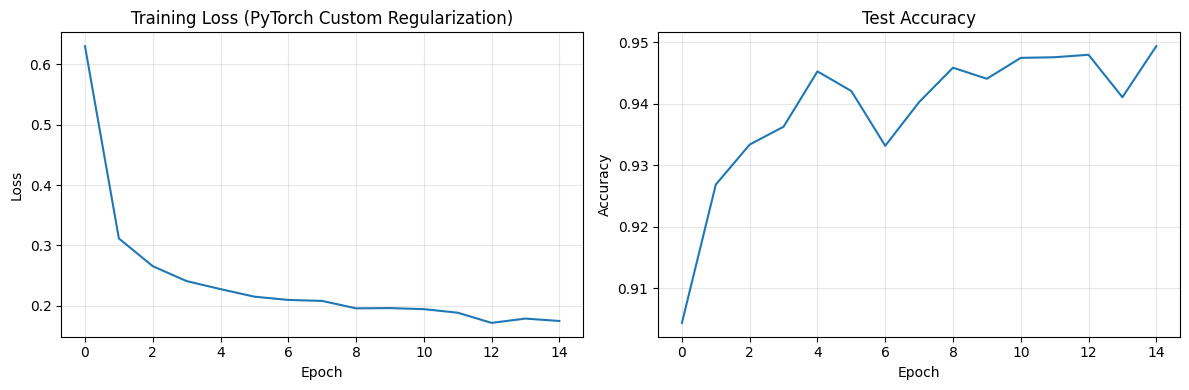

In [19]:
# Plot training results
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_losses)
axes[0].set_title('Training Loss (PyTorch Custom Regularization)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)

axes[1].plot(test_accs)
axes[1].set_title('Test Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Summary

### Custom Dropout Variants:

| Type | Description | Use Case |
|------|-------------|----------|
| **Standard** | Randomly zeros neurons | General purpose |
| **Gaussian** | Multiplies by Gaussian noise | Softer regularization |
| **Spatial** | Drops entire channels | CNNs, sequential data |
| **Alpha** | For SELU networks | Self-normalizing networks |
| **Concrete** | Learns dropout rate | Automatic tuning |

### Custom Regularizers:

| Type | Formula | Effect |
|------|---------|--------|
| **L1** | λ∑|w| | Sparse weights |
| **L2** | λ∑w² | Small weights |
| **Orthogonal** | λ∥W^TW - I∥ | Gradient stability |
| **Max Norm** | λ∑max(0, ∥w∥-c)² | Bounded weights |

### Implementation Tips:
- **TensorFlow**: Subclass `keras.layers.Layer` or `keras.regularizers.Regularizer`
- **PyTorch**: Subclass `nn.Module` and add regularization to loss manually